# Lab 2 - Model Agnostic Methods

**How the lab works**

- The questions are divided into three levels.
  - **[Basic]**: if your group completes all Basic questions of a lab correctly, you get a 6 (a passing grade).
  - **[Regular]**: these questions give up to 2 extra points.
  - **[Advanced]**: for students looking for a challenge; expect to work on them in your own time.
- Every group works with slightly different data and settings, so your answers, numbers and plots are different from those of other groups.
  - Set your group number $G$ in the first code cell. Your seed is $S = G$; use it everywhere a random seed is needed (`random_state=S`).
  - *Your patient* is row $p = S \bmod n$ of your test set, where $n$ is the number of rows in the test set.
  - Put your group number in the title of every plot.
- Answers must use the numbers and plots from your own notebook. An answer that does not match your own output gets no points.
- You may use AI tools to help with code, but every group member must be able to explain what you hand in.
- Lines marked `# TODO` must be completed. Write your answers in the **Your answers** cells.
- Hand in this notebook with all cells run. Also convert the notebook with all cells run into PDF and hand in. 
  

**Data and models.** Use the same group number, data, split and models as in Lab 1, plus a random forest.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xai_lab_utils import group_seed, personal_data_path, your_patient_index
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Fill in your group number. Everything else depends on it.
GROUP_NUMBER = 1

S = group_seed(GROUP_NUMBER)   # use S everywhere a random seed is needed
np.random.seed(S)              # some SHAP functions use numpy's global random generator
print("Group", GROUP_NUMBER, "- seed S =", S)

Group 1 - seed S = 1


In [3]:
# code from Lab 1
df = pd.read_csv(personal_data_path(GROUP_NUMBER), sep=",", header=0, decimal=".")

X = df.drop(columns="target").astype(float)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=S)

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols = ["cp", "restecg", "slope", "ca", "thal"]
bin_cols = ["sex", "fbs", "exang"]

preprocessor = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
     ("bin", "passthrough", bin_cols)],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

logreg = make_pipeline(clone(preprocessor), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
tree = DecisionTreeClassifier(random_state=S).fit(X_train, y_train)
knn = make_pipeline(clone(preprocessor), KNeighborsClassifier(n_neighbors=5)).fit(X_train, y_train)

# odds ratios from Lab 1 (for Q1 a)
odds = pd.Series(np.exp(logreg[-1].coef_[0]), index=logreg[:-1].get_feature_names_out())
print("Odds ratios of the logistic model (Lab 1):")
odds.sort_values().round(2)

Odds ratios of the logistic model (Lab 1):


ca_1.0         0.14
ca_2.0         0.33
sex            0.40
exang          0.52
restecg_2.0    0.52
ca_3.0         0.54
thal_3.0       0.55
slope_1.0      0.61
oldpeak        0.79
trestbps       0.82
chol           0.89
cp_1.0         0.93
fbs            1.03
thal_1.0       1.06
ca_4.0         1.26
thalach        1.26
slope_2.0      1.48
restecg_1.0    1.65
cp_2.0         2.06
age            2.11
cp_3.0         2.35
thal_2.0       2.74
dtype: float64

In [4]:
rf = RandomForestClassifier(n_estimators=300, random_state=S).fit(X_train, y_train)
models = {"logistic": logreg, "tree": tree, "kNN": knn, "random forest": rf}

p = your_patient_index(GROUP_NUMBER, len(X_test))
x_p = X_test.iloc[[p]]

for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(name, "- train accuracy:", round(train_acc, 3), " test accuracy:", round(test_acc, 3), " test AUC:", round(auc, 3))
print("Our patient is row", p, "of the test set, true label:", y_test.iloc[p])
x_p

logistic - train accuracy: 0.858  test accuracy: 0.812  test AUC: 0.888
tree - train accuracy: 1.0  test accuracy: 0.696  test AUC: 0.658
kNN - train accuracy: 0.814  test accuracy: 0.768  test AUC: 0.858
random forest - train accuracy: 1.0  test accuracy: 0.812  test AUC: 0.845
Our patient is row 1 of the test set, true label: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
201,65.0,1.0,3.0,138.0,282.0,1.0,0.0,174.0,0.0,1.4,1.0,1.0,2.0


## Q1) Permutation importance

a) **[Basic]** Before you run it, write down which three attributes you expect to have the highest permutation importance for the logistic model (look at your odds ratios from Lab 1). Then perform permutation importance for the logistic model for all attributes and plot the results. Give a brief interpretation. Was your expectation right?

b) **[Basic]** Which model is most likely to show a bigger difference in prediction when using permutation importance? Run it for all models and make a table with the top 5 attributes of each model.

c) **[Regular]** Run permutation importance for the random forest on the training set and on the test set. What is the difference? What does it tell you about the model?

d) **[Advanced]** Add a copy of `thalach` with a little noise to the data and run permutation importance again. What happens to the importance of `thalach`? Why?

e) **[Advanced]** Add a column of random numbers. Compare the built-in `feature_importances_` of the random forest with permutation importance. Which one gives importance to the random column, and why?

> **Hint:** `permutation_importance(model, X_test, y_test, n_repeats=30, random_state=S)`; `r.importances_mean`, `r.importances_std`

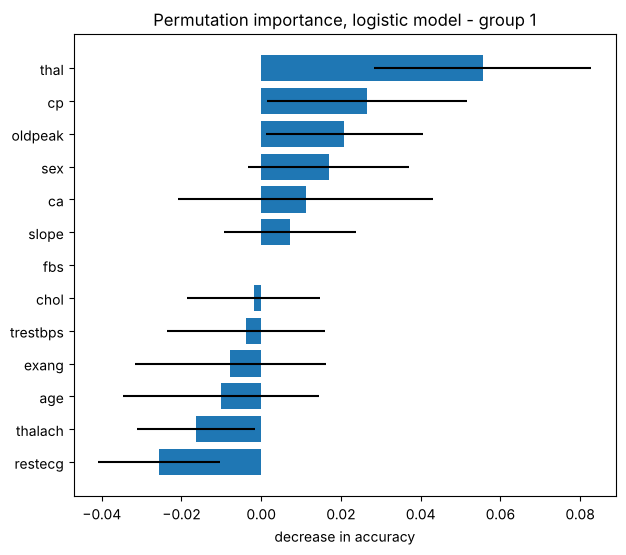

Logistic model: permutation importance on the test set (mean and std over 30 repeats)


,mean,std
thal,0.056,0.027
cp,0.027,0.025
oldpeak,0.021,0.020
sex,0.017,0.020
ca,0.011,0.032
slope,0.007,0.017
fbs,0.000,0.000
chol,-0.002,0.017
trestbps,-0.004,0.020
exang,-0.008,0.024


In [5]:
r = permutation_importance(logreg, X_test, y_test, n_repeats=30, random_state=S)

imp = pd.DataFrame({"mean": r.importances_mean, "std": r.importances_std},
                   index=X_test.columns).sort_values("mean")
plt.figure(figsize=(7, 6))
plt.barh(imp.index, imp["mean"], xerr=imp["std"])
plt.xlabel("decrease in accuracy")
plt.title(f"Permutation importance, logistic model - group {GROUP_NUMBER}")
plt.show()
print("Logistic model: permutation importance on the test set (mean and std over 30 repeats)")
imp.sort_values("mean", ascending=False).round(3)

In [6]:
# (b) all models
perm = pd.DataFrame()
for name, model in models.items():
    r = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=S)
    perm[name] = pd.Series(r.importances_mean, index=X_test.columns)

top5 = pd.DataFrame({name: perm[name].sort_values(ascending=False).index[:5] for name in perm})
print("Top 5 attributes per model (permutation importance on the test set):")
print(top5)
print()
print("Permutation importance (mean decrease in test accuracy) of every attribute, per model:")
print(perm.round(3))

Top 5 attributes per model (permutation importance on the test set):
  logistic      tree      kNN random forest
0     thal      thal     thal          thal
1       cp     slope  oldpeak            cp
2  oldpeak        ca       cp         exang
3      sex  trestbps    slope         slope
4       ca       age      fbs       oldpeak

Permutation importance (mean decrease in test accuracy) of every attribute, per model:
          logistic   tree    kNN  random forest
age         -0.010  0.015 -0.006         -0.001
sex          0.017 -0.007 -0.003          0.010
cp           0.027  0.000  0.016          0.032
trestbps    -0.004  0.054 -0.004          0.008
chol        -0.002  0.000 -0.008          0.010
fbs          0.000 -0.013  0.004          0.003
restecg     -0.026  0.000 -0.004          0.011
thalach     -0.016 -0.002 -0.023         -0.004
exang       -0.008 -0.012 -0.014          0.023
oldpeak      0.021 -0.000  0.058          0.021
slope        0.007  0.067  0.010          0.021
ca 

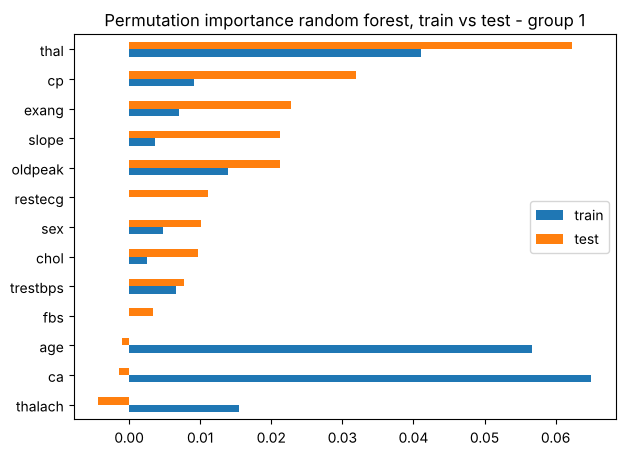

Random forest: permutation importance on the training set and on the test set


,train,test
thal,0.041,0.062
cp,0.009,0.032
exang,0.007,0.023
slope,0.004,0.021
oldpeak,0.014,0.021
restecg,0.000,0.011
sex,0.005,0.010
chol,0.002,0.010
trestbps,0.007,0.008
fbs,0.000,0.003


In [7]:
# (c) random forest on train and test set
r_train = permutation_importance(rf, X_train, y_train, n_repeats=30, random_state=S)
r_test = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=S)
rf_imp = pd.DataFrame({"train": r_train.importances_mean, "test": r_test.importances_mean}, index=X.columns)
rf_imp.sort_values("test").plot.barh(figsize=(7, 5))
plt.title(f"Permutation importance random forest, train vs test - group {GROUP_NUMBER}")
plt.show()
print("Random forest: permutation importance on the training set and on the test set")
rf_imp.sort_values("test", ascending=False).round(3)

In [8]:
# (d) add a noisy copy of thalach
X2 = X.copy()
X2["thalach_copy"] = X2["thalach"] + np.random.default_rng(S).normal(0, 2, len(X2))
X2_train, X2_test = X2.loc[X_train.index], X2.loc[X_test.index]
rf2 = RandomForestClassifier(n_estimators=300, random_state=S).fit(X2_train, y_train)

r2 = permutation_importance(rf2, X2_train, y_train, n_repeats=30, random_state=S)
print("permutation importance on train, without copy: thalach", round(r_train.importances_mean[7], 3))
print("permutation importance on train, with copy: thalach", round(r2.importances_mean[7], 3),
      " thalach_copy", round(r2.importances_mean[13], 3))
print("feature_importances_ without copy: thalach", round(rf.feature_importances_[7], 3))
print("feature_importances_ with copy: thalach", round(rf2.feature_importances_[7], 3),
      " thalach_copy", round(rf2.feature_importances_[13], 3))

permutation importance on train, without copy: thalach 0.016
permutation importance on train, with copy: thalach 0.0  thalach_copy 0.002
feature_importances_ without copy: thalach 0.132
feature_importances_ with copy: thalach 0.099  thalach_copy 0.107


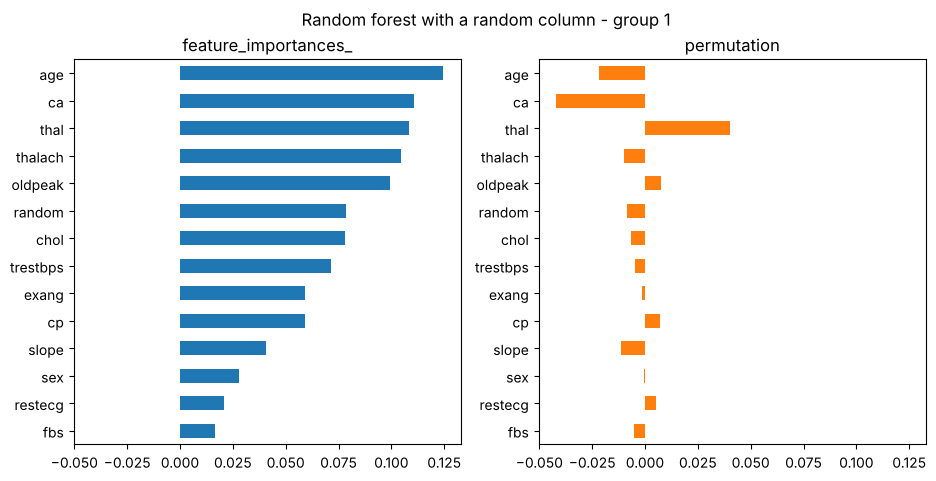

Random forest with a random column: built-in importance vs permutation importance (test set)


,feature_importances_,permutation
age,0.125,-0.022
ca,0.111,-0.042
thal,0.109,0.040
thalach,0.105,-0.010
oldpeak,0.099,0.008
random,0.079,-0.009
chol,0.078,-0.007
trestbps,0.072,-0.005
exang,0.059,-0.001
cp,0.059,0.007


In [9]:
# (e) add a random column
X3 = X.copy()
X3["random"] = np.random.default_rng(S).normal(size=len(X3))
X3_train, X3_test = X3.loc[X_train.index], X3.loc[X_test.index]
rf3 = RandomForestClassifier(n_estimators=300, random_state=S).fit(X3_train, y_train)
r3 = permutation_importance(rf3, X3_test, y_test, n_repeats=30, random_state=S)

comp = pd.DataFrame({"feature_importances_": rf3.feature_importances_,
                     "permutation": r3.importances_mean}, index=X3.columns)
comp.sort_values("feature_importances_").plot.barh(subplots=True, layout=(1, 2), figsize=(11, 5), legend=False)
plt.suptitle(f"Random forest with a random column - group {GROUP_NUMBER}")
plt.show()
print("Random forest with a random column: built-in importance vs permutation importance (test set)")
comp.sort_values("feature_importances_", ascending=False).round(3)

**Your answers:**

a) From the odds ratios in Lab 1 we expected ca (OR 0.14 for ca=1), thal (OR 2.74 for thal=2) and sex (OR 0.40) to be the most important. The plot shows thal (0.056), cp (0.027) and oldpeak (0.021) as the top 3, sex is 4th and ca only 5th. So our expectation was only partly right. Most values are very small and the standard deviations are about as large as the means, because the test set has only 69 patients (one patient is already 1.4% accuracy). The negative values (restecg, thalach, age) basically mean the attribute is not important. A big odds ratio does not automatically mean a big drop in accuracy, because permutation importance only counts predictions that change class.

b) We expected the decision tree, because it is not pruned and makes hard splits, so shuffling one attribute can send a patient into a completely different leaf. This is what we see: the tree has the largest importances (thal 0.082, slope 0.067, ca 0.056, trestbps 0.054), while the logistic model has the smallest. thal is the most important attribute for all four models.

| | logistic | tree | kNN | random forest |
|---|---|---|---|---|
| 1 | thal | thal | thal | thal |
| 2 | cp | slope | oldpeak | cp |
| 3 | oldpeak | ca | cp | exang |
| 4 | sex | trestbps | slope | slope |
| 5 | ca | age | fbs | oldpeak |

c) On the training set ca (0.065) and age (0.057) are the most important, but on the test set they are about 0. The random forest has a training accuracy of 1.0 (see the output of the setup cell, test accuracy 0.812), so on the training set it has memorised these attributes, but this does not generalise to new patients. This means the model overfits, and permutation importance should be computed on the test set.

d) With the copy, the importance of thalach on the training set goes from 0.016 to 0.000 (copy: 0.002). The built-in importance is split between the two (0.132 becomes 0.099 + 0.107). When we shuffle thalach, the model can still use the copy, which contains the same information, so the accuracy does not drop. Correlated attributes therefore share or hide each other's importance.

e) The built-in feature_importances_ gives the random column 0.079 (6th place, higher than cp, exang and sex), while permutation importance gives it -0.009, so about 0. feature_importances_ is calculated on the training data from how much the splits reduce the impurity. A continuous random column has many possible split points, so the trees can always use it to fit the training data. Permutation importance on the test set only shows attributes that actually help on new data.

## Q2) Partial dependence and ICE

a) **[Basic]** Choose the two attributes you think explain the most, and motivate your choice. For each model, plot the partial dependence plot (PDP) of these attributes together with the ICE curves. Comment on the differences between the models. Do all patients behave the same way? Point to a place in your plot where the PDP hides something.

b) **[Basic]** Plot the two-way PDP of `trestbps` (resting blood pressure) and `cp` (chest pain type) and explain their effect.

c) **[Advanced]** Write your own code for the Ceteris Paribus profile (algorithm in the lecture) of your patient for `thalach` and for `cp`. Compare it with the PDP.

d) **[Advanced]** Plot the PDP of the logistic model once on the probability scale and once on the log-odds scale. Why is one of them a straight line?

> **Hint:** `PartialDependenceDisplay.from_estimator(model, X_test, features, kind="both", centered=True)`;
> two-way: `features=[("trestbps", "cp")], categorical_features=["cp"]`; log-odds scale: `response_method="decision_function"`

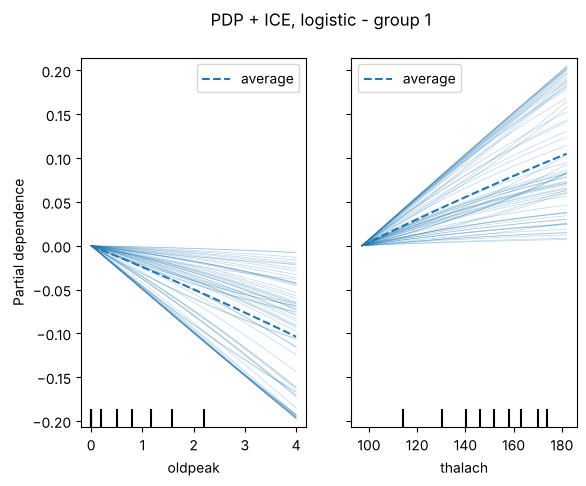

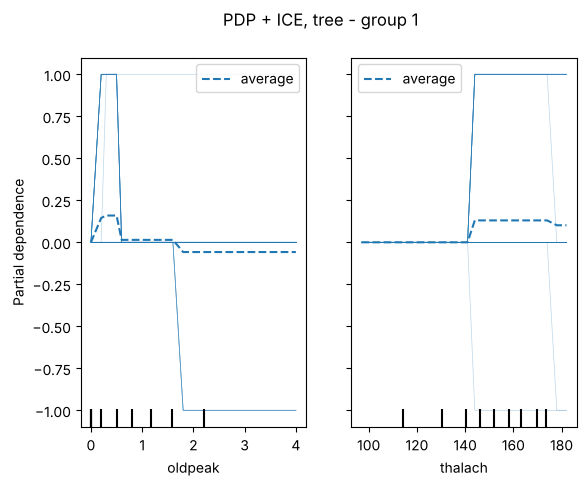

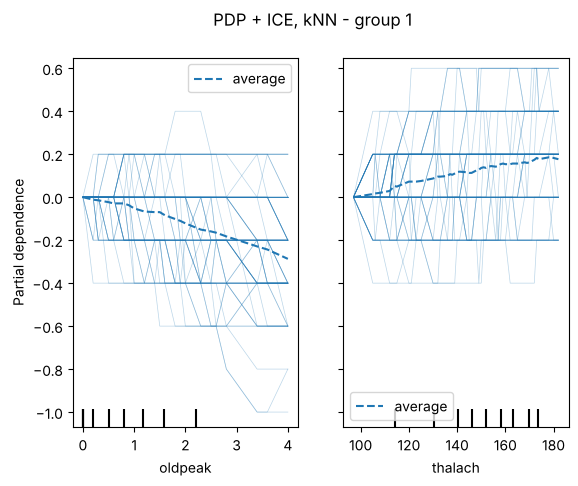

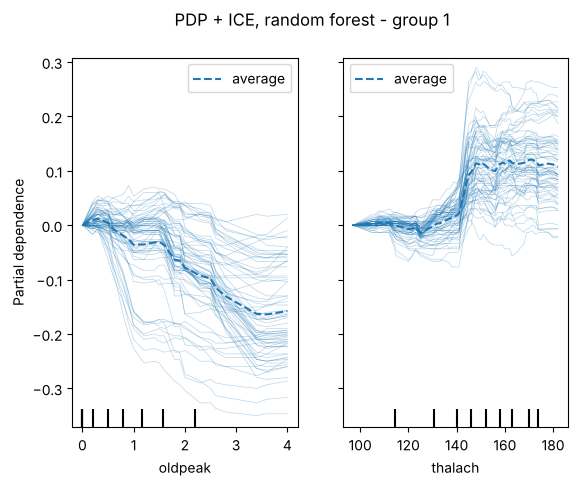

In [10]:
features = ["oldpeak", "thalach"]  # (a)

for name, model in models.items():
    disp = PartialDependenceDisplay.from_estimator(
        model, X_test, features, kind="both", centered=True, random_state=S)
    disp.figure_.suptitle(f"PDP + ICE, {name} - group {GROUP_NUMBER}")
    plt.show()

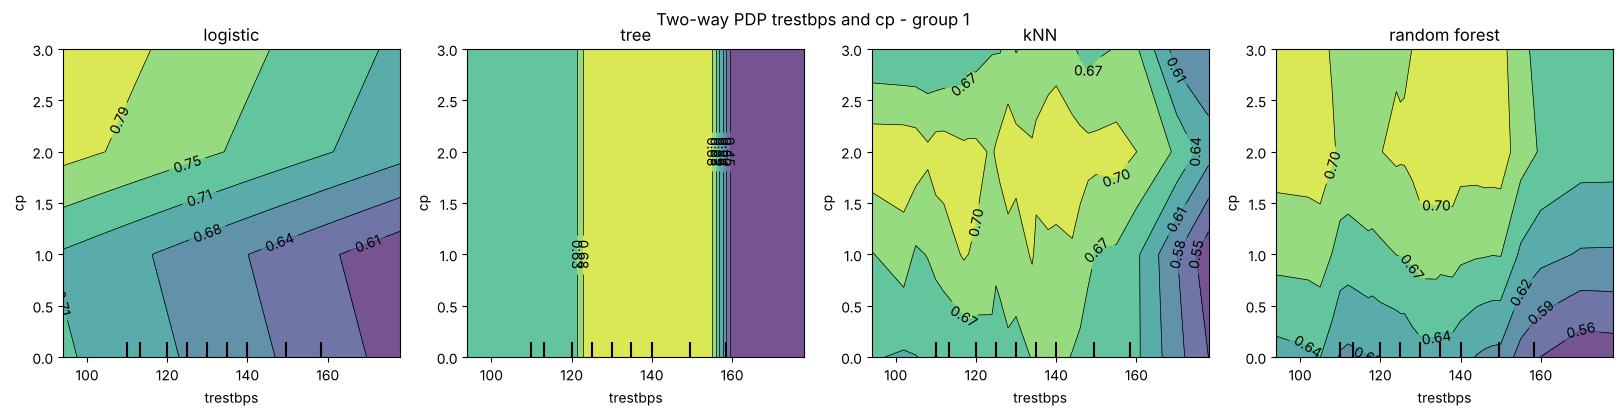

In [11]:
# (b) two-way PDP of trestbps and cp
# categorical_features=["cp"] gives an error in our scikit-learn version for a numeric + categorical pair,
# so cp is used as a number (it only has the values 0, 1, 2, 3)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    PartialDependenceDisplay.from_estimator(model, X_test, [("trestbps", "cp")], random_state=S, ax=ax)
    ax.set_title(name)
fig.suptitle(f"Two-way PDP trestbps and cp - group {GROUP_NUMBER}")
plt.show()

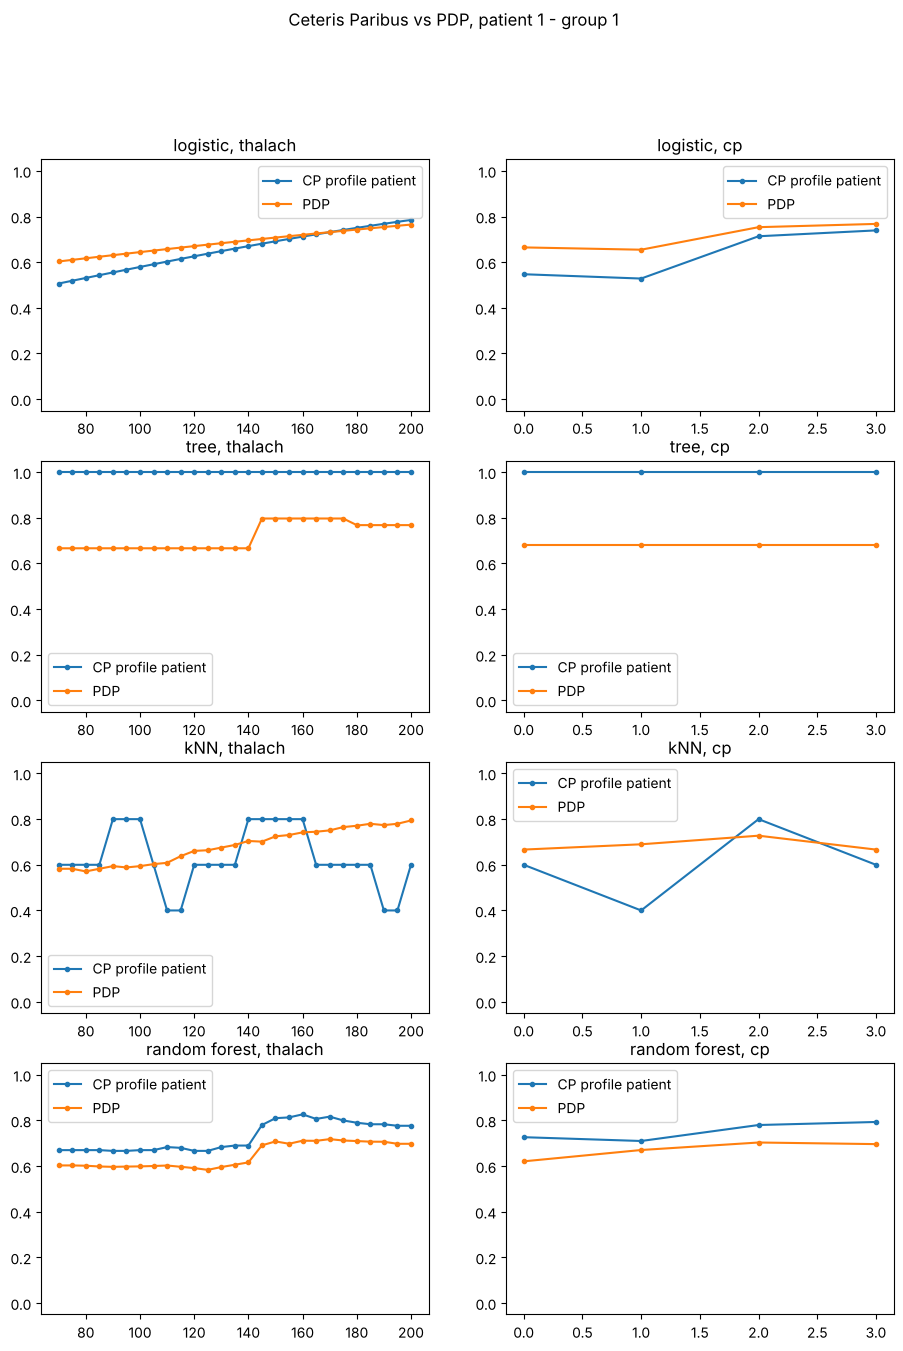

P(disease) for cp = 0, 1, 2, 3: CP profile of our patient vs PDP
  logistic       CP: [0.55 0.53 0.71 0.74]  PDP: [0.66 0.65 0.75 0.77]
  tree           CP: [1. 1. 1. 1.]  PDP: [0.68 0.68 0.68 0.68]
  kNN            CP: [0.6 0.4 0.8 0.6]  PDP: [0.67 0.69 0.73 0.67]
  random forest  CP: [0.73 0.71 0.78 0.79]  PDP: [0.62 0.67 0.7  0.7 ]
P(disease) for thalach = 70 and thalach = 200: CP profile of our patient vs PDP
  logistic       CP: [0.51 0.79]  PDP: [0.6  0.76]
  tree           CP: [1. 1.]  PDP: [0.67 0.77]
  kNN            CP: [0.6 0.6]  PDP: [0.58 0.79]


  random forest  CP: [0.67 0.78]  PDP: [0.6 0.7]


In [12]:
# (c) Ceteris Paribus profile of our patient
def ceteris_paribus(model, x, feature, values):
    rows = pd.concat([x] * len(values))
    rows[feature] = values
    return model.predict_proba(rows)[:, 1]

def pdp(model, X, feature, values):
    return [model.predict_proba(X.assign(**{feature: v}))[:, 1].mean() for v in values]

values = {"thalach": np.arange(70, 205, 5), "cp": [0, 1, 2, 3]}
fig, axes = plt.subplots(4, 2, figsize=(11, 15))
for i, name in enumerate(models):
    for j, f in enumerate(["thalach", "cp"]):
        axes[i, j].plot(values[f], ceteris_paribus(models[name], x_p, f, values[f]), marker=".", label="CP profile patient")
        axes[i, j].plot(values[f], pdp(models[name], X_test, f, values[f]), marker=".", label="PDP")
        axes[i, j].set_title(f"{name}, {f}")
        axes[i, j].set_ylim(-0.05, 1.05)
        axes[i, j].legend()
fig.suptitle(f"Ceteris Paribus vs PDP, patient {p} - group {GROUP_NUMBER}")
plt.show()

print("P(disease) for cp = 0, 1, 2, 3: CP profile of our patient vs PDP")
for name, model in models.items():
    print(f"  {name:14s} CP:", np.round(ceteris_paribus(model, x_p, "cp", values["cp"]), 2),
          " PDP:", np.round(pdp(model, X_test, "cp", values["cp"]), 2))
print("P(disease) for thalach = 70 and thalach = 200: CP profile of our patient vs PDP")
for name, model in models.items():
    print(f"  {name:14s} CP:", np.round(ceteris_paribus(model, x_p, "thalach", [70, 200]), 2),
          " PDP:", np.round(pdp(model, X_test, "thalach", [70, 200]), 2))

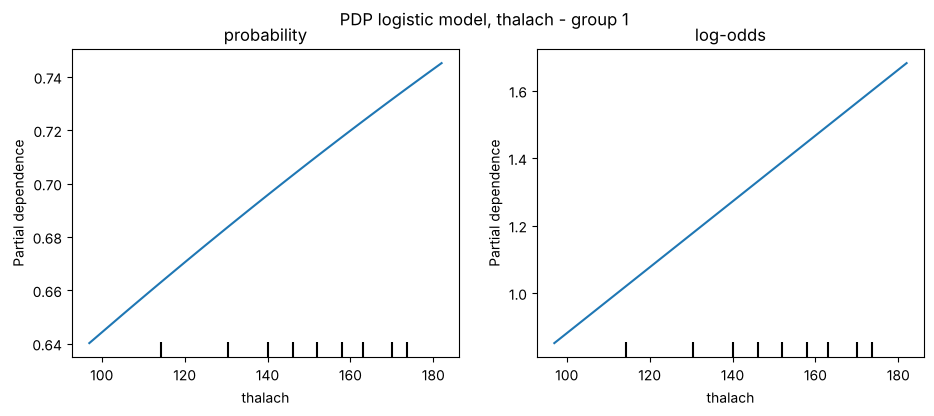

In [13]:
# (d) probability vs log-odds
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(logreg, X_test, ["thalach"], random_state=S, ax=axes[0])
PartialDependenceDisplay.from_estimator(logreg, X_test, ["thalach"], response_method="decision_function",
                                        random_state=S, ax=axes[1])
axes[0].set_title("probability"); axes[1].set_title("log-odds")
fig.suptitle(f"PDP logistic model, thalach - group {GROUP_NUMBER}")
plt.show()

**Your answers:**

a) We chose oldpeak and thalach. They are continuous, have a high correlation with the target and are in the top 5 of the permutation importance for several models (thal and cp are higher but are categorical).
- Logistic: smooth lines, higher oldpeak gives lower probability and higher thalach gives higher probability. All ICE lines go in the same direction.
- Tree: step functions. Most ICE lines are flat and only a few patients jump by +1 or -1.
- kNN: very jagged lines with steps of 0.2 (1/k).
- Random forest: like a smoothed tree. oldpeak only has an effect above about 1.5, and thalach has a jump around 140-145.

Not all patients behave the same, for example for the random forest some ICE lines of oldpeak drop already at 1 and others hardly change. The PDP hides something for the tree and thalach: the PDP only shows a small step of about 0.13 at 142, but the individual patients either do not change or jump by 1 (and a few drop by 1 around 175).

b) For the logistic model the contour lines are parallel: a higher cp gives a higher probability and a higher trestbps a lower probability (from 0.79 for cp=3 and low trestbps to 0.61 for cp=0 and high trestbps). There is no interaction, the effects just add up. For the random forest trestbps has almost no effect until about 150 and then the probability drops, and cp=0 gives the lowest probability. The tree only uses trestbps (vertical bands). Medically it is strange that a higher blood pressure lowers the risk, but the PDP only shows what the model learned from this data, not causality.

c) The Ceteris Paribus profile takes our patient, changes only one attribute and keeps the rest the same. The PDP is the average of these profiles over all patients.
- Logistic: the profile has the same shape as the PDP. For thalach it is a bit steeper (0.51 to 0.79, PDP 0.60 to 0.76), for cp it is lower for cp = 0 and 1 (0.55 and 0.53, PDP 0.66 and 0.65) but almost the same for cp = 2 and 3.
- Tree: the profile is 1.0 everywhere, while the PDP is 0.68 for every cp and goes from 0.67 to 0.77 for thalach. The tree predicts disease for our patient whatever thalach or cp is, because these attributes are not on the path of our patient in the tree. The jump of the PDP at thalach = 142 comes from other patients.
- kNN: the profile jumps between 0.4 and 0.8 (every time the 5 neighbours change), while the PDP is smooth. For example cp = 1 gives 0.4 for our patient but 0.69 on average.
- Random forest: the profile is 0.04 to 0.11 higher than the PDP (for example 0.78 vs 0.70 at thalach = 200), but it has the same jump at thalach = 140 and the same almost flat shape for cp.

So the PDP is a good summary of our patient only for the logistic model and the random forest. For the tree and kNN our patient behaves very differently from the average. Our patient has thalach = 174 and cp = 3, so for all models they are on the high part of the curves.

d) On the log-odds scale the logistic model is linear: log-odds = b0 + sum of b_j x_j. If we change one attribute and average over the patients, the result is b_j x_j + constant, so a straight line. On the probability scale the sigmoid function is applied, so it is not exactly linear, but here it looks almost straight because the probabilities are between 0.64 and 0.75.

## Q3) SHAP

*Note:* for the force plot the notebook must be trusted (`shap.initjs()`).

a) **[Basic]** Use a SHAP explainer to derive the SHAP values for the logistic model (code below). Plot a SHAP summary plot using all attributes and explain the plot. Compare the order of the attributes with permutation importance.

b) **[Basic]** Plot the SHAP dependence plot for `exang`. Explain how to read this plot, and how it differs from a PDP.

c) **[Basic]** Plot a force plot and a waterfall plot for your patient and explain the figures. Check that the base value plus the sum of the SHAP values equals the model output for your patient. Give the numbers.

d) **[Regular]** For the logistic model, the SHAP value of attribute $j$ is $\beta_j (x_j - \text{mean}(x_j))$ on the log-odds scale. Check this for your patient with your numbers.

e) **[Advanced]** Find a patient in your test set whose most important attribute (by SHAP) is not the globally most important one. Explain why this is not a contradiction.

f) **[Advanced]** Use KernelSHAP with a background of 10, 50 and 200 patients. How much do the SHAP values change? How long does each run take?

> **Hint:** `shap.plots.beeswarm(sv)`, `shap.plots.bar(sv)`, `shap.plots.scatter(sv[:, "exang"], color=sv)`;
> `shap.plots.waterfall(sv[p])`, `shap.plots.force(sv[p])`; `sv.base_values[p]`, `sv.values[p].sum()`, `clf.decision_function(Xt_test)[p]`;
> `shap.KernelExplainer(f, shap.sample(X_train, 50, random_state=S))`

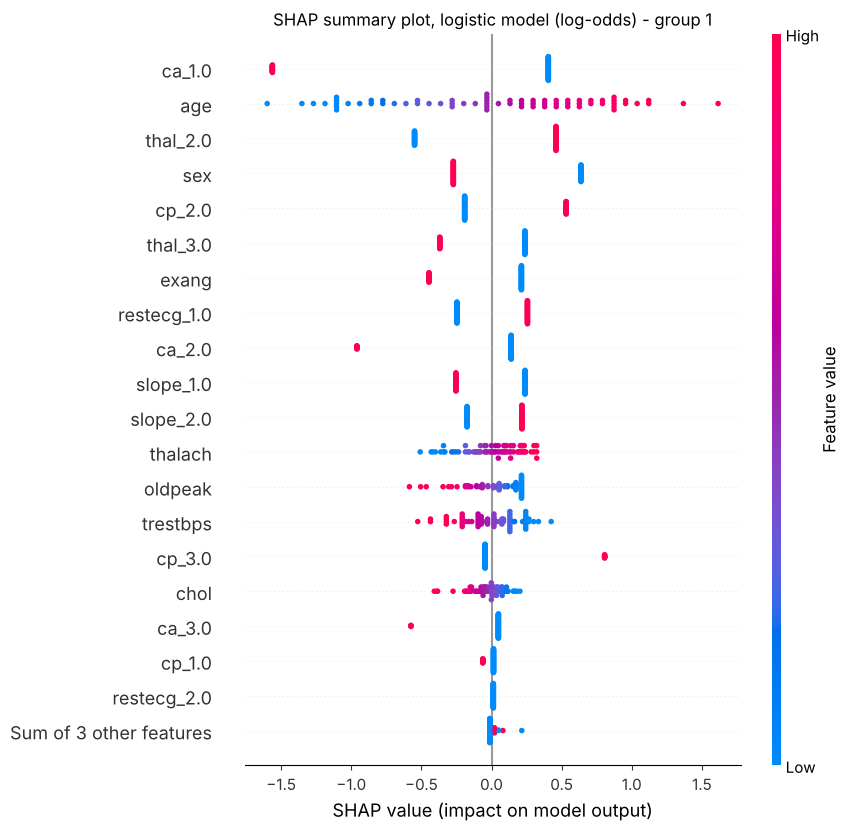

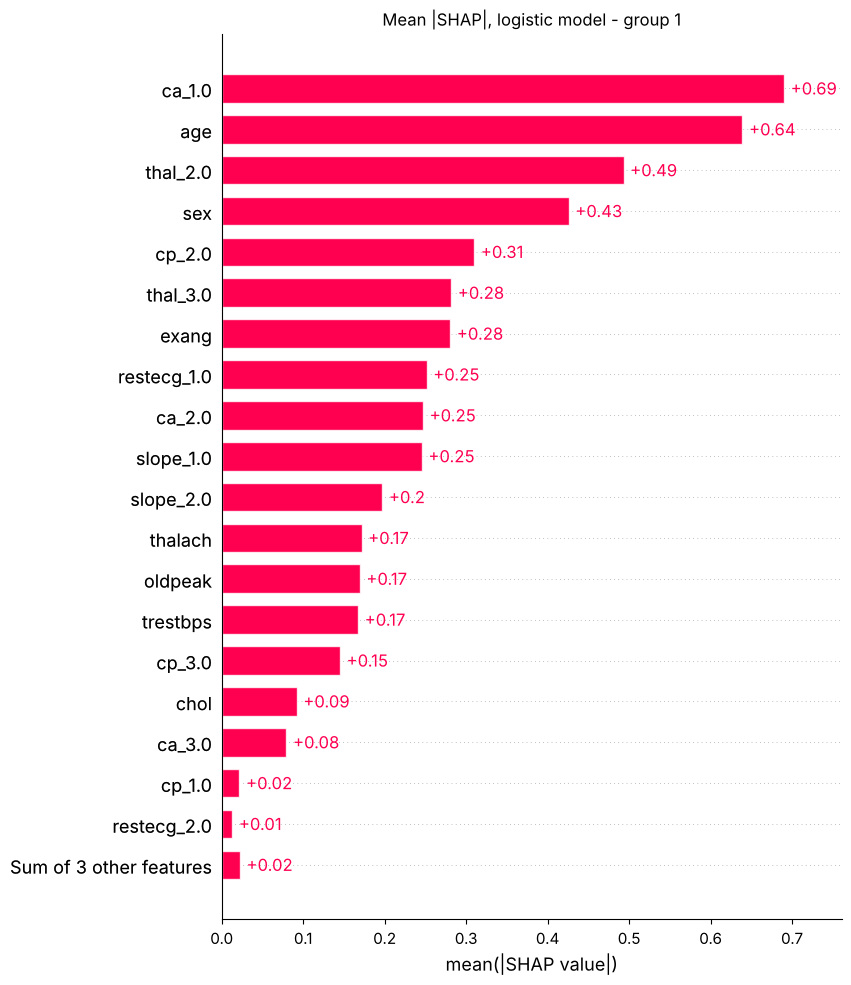

In [14]:
shap.initjs()

# SHAP for the logistic model, on the preprocessed (scaled) data.
# The values are on the log-odds scale.
pre, clf = logreg[:-1], logreg[-1]
Xt_train, Xt_test = pre.transform(X_train), pre.transform(X_test)

# Use the full training set as background (by default SHAP keeps only 100 rows)
masker = shap.maskers.Independent(Xt_train, max_samples=len(Xt_train))
explainer = shap.LinearExplainer(clf, masker)
sv = explainer(Xt_test)

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title(f"SHAP summary plot, logistic model (log-odds) - group {GROUP_NUMBER}")
plt.show()
shap.plots.bar(sv, max_display=20, show=False)
plt.title(f"Mean |SHAP|, logistic model - group {GROUP_NUMBER}")
plt.show()

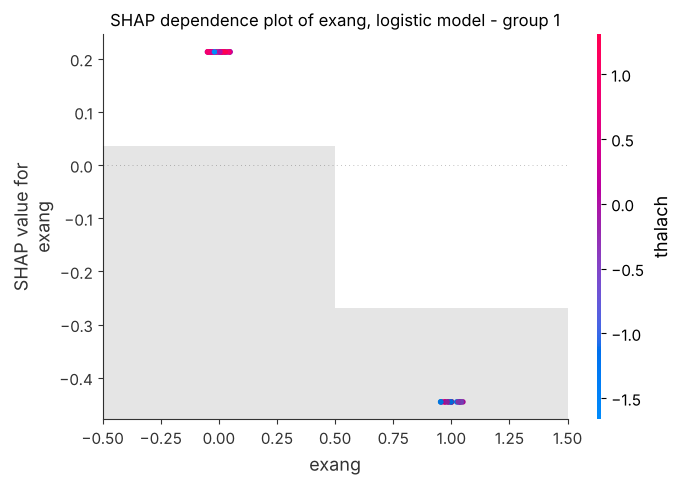

SHAP value of exang for exang = 0 and exang = 1:
0.0    0.213
1.0   -0.446
dtype: float64


In [15]:
# (b) dependence plot for exang
shap.plots.scatter(sv[:, "exang"], color=sv, show=False)
plt.title(f"SHAP dependence plot of exang, logistic model - group {GROUP_NUMBER}")
plt.show()
print("SHAP value of exang for exang = 0 and exang = 1:")
print(pd.Series(sv[:, "exang"].values).groupby(X_test["exang"].values).mean().round(3))

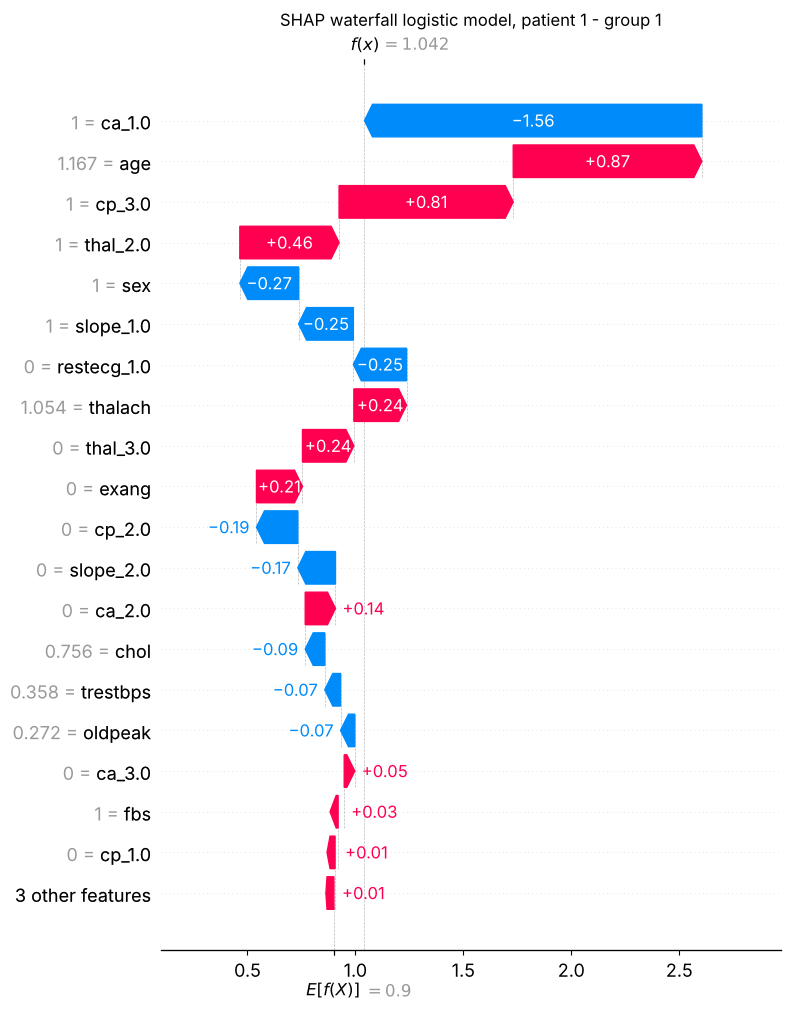

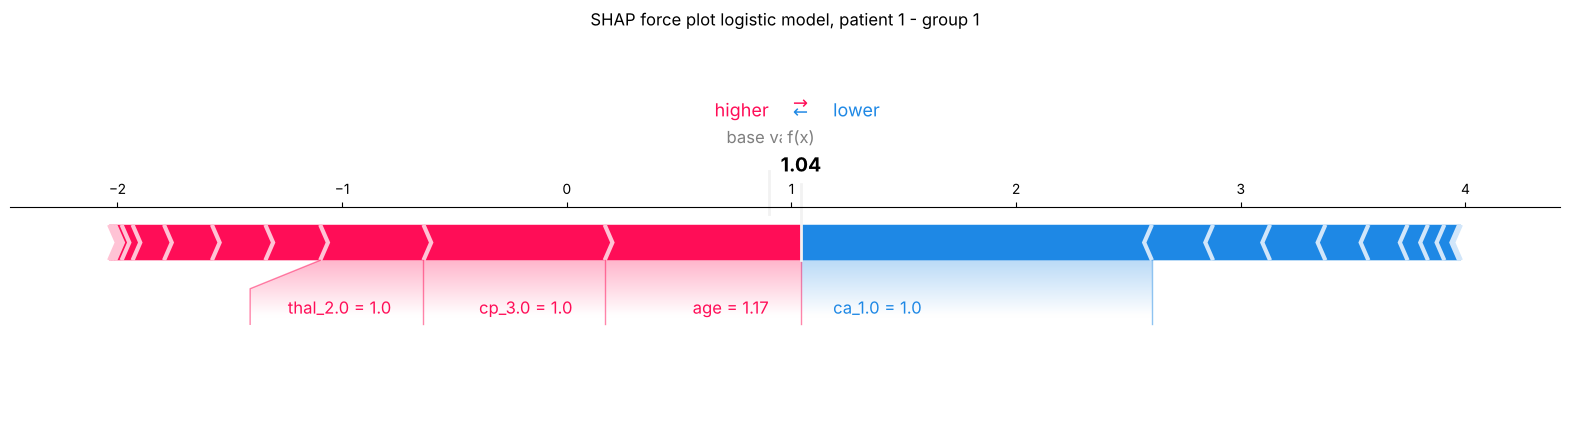

base value: 0.9004170765194582
sum of SHAP values: 0.1416254495571303
base + sum: 1.0420425260765884
decision_function: 1.0420425260765889
predict_proba: 0.7392439205575763  true label: 0


In [16]:
# (c) your patient
shap.plots.waterfall(sv[p], max_display=20, show=False)
plt.title(f"SHAP waterfall logistic model, patient {p} - group {GROUP_NUMBER}")
plt.show()
shap.plots.force(sv.base_values[p], sv.values[p], Xt_test.iloc[p].round(2), matplotlib=True, show=False,
                 contribution_threshold=0.1)
plt.title(f"SHAP force plot logistic model, patient {p} - group {GROUP_NUMBER}", y=1.75)
plt.show()

print("base value:", sv.base_values[p])
print("sum of SHAP values:", sv.values[p].sum())
print("base + sum:", sv.base_values[p] + sv.values[p].sum())
print("decision_function:", clf.decision_function(Xt_test)[p])
print("predict_proba:", logreg.predict_proba(x_p)[0, 1], " true label:", y_test.iloc[p])

In [17]:
# (d) beta * (x - mean) for our patient
check = pd.DataFrame({"beta": clf.coef_[0], "x": Xt_test.iloc[p], "mean": Xt_train.mean()})
check["beta*(x-mean)"] = check["beta"] * (check["x"] - check["mean"])
check["shap"] = sv.values[p]
print("Our patient: beta * (x - mean) compared with the SHAP value of every attribute")
check.round(4)

Our patient: beta * (x - mean) compared with the SHAP value of every attribute


,beta,x,mean,beta*(x-mean),shap
age,0.7487,1.1668,0.0000,0.8735,0.8735
trestbps,-0.2037,0.3581,-0.0000,-0.0729,-0.0729
chol,-0.1200,0.7560,0.0000,-0.0907,-0.0907
thalach,0.2315,1.0541,-0.0000,0.2440,0.2440
oldpeak,-0.2417,0.2723,0.0000,-0.0658,-0.0658
cp_1.0,-0.0760,0.0000,0.1863,0.0142,0.0142
cp_2.0,0.7234,0.0000,0.2647,-0.1915,-0.1915
cp_3.0,0.8526,1.0000,0.0539,0.8066,0.8066
restecg_1.0,0.5025,0.0000,0.4902,-0.2463,-0.2463
restecg_2.0,-0.6575,0.0000,0.0196,0.0129,0.0129


global most important: ca_1.0
patient 0 most important: age
SHAP values of patient 0: age = -1.105 , ca_1.0 = 0.405


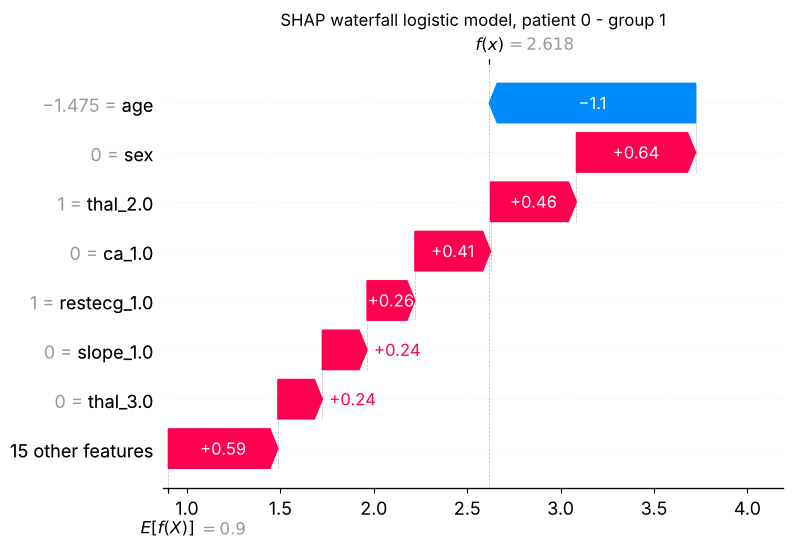

In [18]:
# (e) patient whose most important attribute is not the global one
global_top = sv.feature_names[np.abs(sv.values).mean(axis=0).argmax()]
print("global most important:", global_top)
for i in range(len(Xt_test)):
    local_top = sv.feature_names[np.abs(sv.values[i]).argmax()]
    if local_top != global_top:
        print("patient", i, "most important:", local_top)
        break
print(f"SHAP values of patient {i}: {local_top} =", round(sv[i, local_top].values, 3),
      f", {global_top} =", round(sv[i, global_top].values, 3))
shap.plots.waterfall(sv[i], max_display=8, show=False)
plt.title(f"SHAP waterfall logistic model, patient {i} - group {GROUP_NUMBER}")
plt.show()

In [19]:
# (f) KernelSHAP with different background sizes (the run time depends on the computer)
for n_bg in [10, 50, 200]:
    background = shap.sample(Xt_train, n_bg, random_state=S)
    np.random.seed(S)   # KernelSHAP samples the coalitions with numpy's random generator
    start = time.time()
    kernel = shap.KernelExplainer(clf.decision_function, background)
    kv = kernel.shap_values(Xt_test, nsamples=500, silent=True)
    print(n_bg, "patients: time", round(time.time() - start, 1), "s,",
          "base value", round(kernel.expected_value, 3), ",",
          "mean abs difference with LinearExplainer", round(np.abs(kv - sv.values).mean(), 3))

10 patients: time 0.6 s, base value 1.096 , mean abs difference with LinearExplainer 0.091


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


50 patients: time 0.7 s, base value 0.757 , mean abs difference with LinearExplainer 0.067


200 patients: time 1.0 s, base value 0.859 , mean abs difference with LinearExplainer 0.067


**Your answers:**

a) Every dot is one patient, the x-axis is the SHAP value (how much the attribute changes the log-odds compared to the average), and the colour is the value of the attribute. The attributes are sorted by mean |SHAP|. ca_1 is the most important: ca=1 gives about -1.56 and ca=0 about +0.4. A high age increases the log-odds, a high thalach also, and a high oldpeak or exang=1 decreases them. Compared to permutation importance both have thal and ca near the top, but age is very high for SHAP and almost 0 for permutation importance (and oldpeak the other way around). SHAP shows how much an attribute changes the prediction, while permutation importance shows how much the accuracy drops, and these are not the same.

b) The plot shows for every patient the value of exang on the x-axis and its SHAP value on the y-axis (colour = thalach). exang=0 always gives +0.213 and exang=1 always gives -0.446. The difference 0.659 is equal to the absolute value of the coefficient of exang (-0.6586, see the table in d). There is no spread, because the logistic model has no interactions. A PDP shows the average prediction when we set exang to a value for all patients, while the SHAP plot shows the contribution for each real patient. With interactions the SHAP plot would show a vertical spread.

c) The waterfall plot starts at the base value E[f(X)] = 0.900 (average log-odds) and adds the SHAP value of every attribute, ending at f(x) = 1.042. ca=1 decreases the log-odds the most (-1.56), and age (+0.87), cp=3 (+0.81) and thal=2 (+0.46) increase them. The force plot shows the same: red pushes up, blue pushes down.
Check: 0.9004 + 0.1416 = 1.0420, which is the same as decision_function (1.0420). This gives a probability of 0.739. The patient actually has no heart disease, so the model is wrong for this patient.

d) For example for age: 0.7487 * (1.1668 - 0) = 0.8735, which is the SHAP value. For ca_1: -1.9674 * (1 - 0.2059) = -1.5624, also the same. The table shows that this holds for all attributes. The mean of the scaled numerical attributes is 0, so for those SHAP = beta * x.

e) Globally ca_1 is the most important, but for patient 0 age is the most important (SHAP -1.105, because the patient is young), while ca_1 only gives +0.405. This is not a contradiction, because the global importance is the average over all patients. ca_1 is very important for the patients with ca=1, but age can be more important for patients with a very low or very high age.

f) The run times were 0.6 s, 0.7 s and 1.0 s for 10, 50 and 200 patients (this depends on the computer). The base value changes a lot (1.096, 0.757, 0.859 instead of 0.900), because SHAP values are always compared to the mean of the background. The mean absolute difference with the exact values goes from 0.091 (10 patients) to 0.067 (50 and 200 patients). So a background of 10 is too small, and above 50 it hardly improves, because the rest of the difference is the sampling error of KernelSHAP itself. More background means more accurate but slower.

## Q4) Compare two models

a) **[Basic]** Derive the SHAP values for the random forest (code below). Together with your results from Q1 and Q2, compare and contrast the random forest with the logistic model. Which model is more sensitive to which attributes?

b) **[Regular]** Show the SHAP waterfall plot of your patient for both models. Which explanation would you show to a doctor? Why? Assess permutation importance, PDP and SHAP on completeness, comprehensibility and stability.

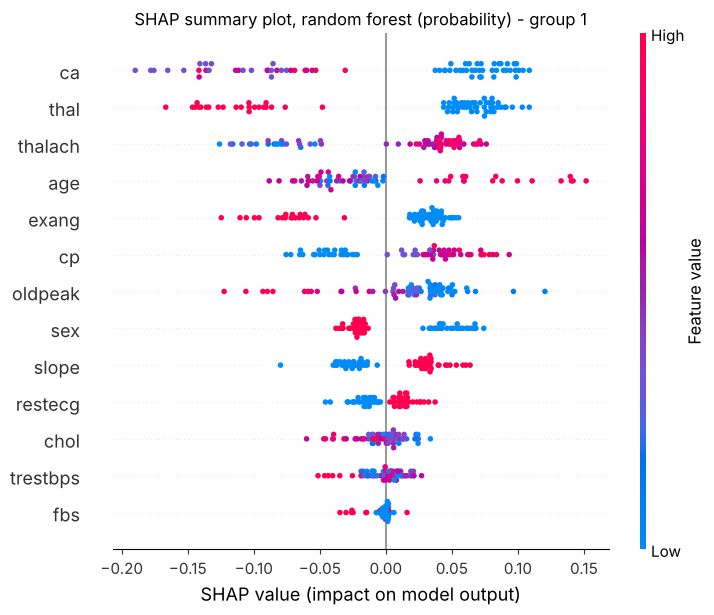

Random forest: mean SHAP value of thal per value of thal
       mean  count
thal              
1.0   0.049      3
2.0   0.070     43
3.0  -0.114     23

Random forest: mean SHAP value of ca per value of ca
      mean  count
ca               
0.0  0.074     38
1.0 -0.125     17
2.0 -0.096      9
3.0 -0.072      4
4.0 -0.069      1

Random forest: mean |SHAP| per attribute


ca          0.089
thal        0.084
thalach     0.057
age         0.049
exang       0.046
cp          0.045
oldpeak     0.039
sex         0.034
slope       0.031
restecg     0.016
chol        0.013
trestbps    0.012
fbs         0.004
dtype: float64

In [20]:
# SHAP for the random forest (exact and fast for trees)
explainer_rf = shap.TreeExplainer(rf)
sv_rf = explainer_rf(X_test)
if sv_rf.values.ndim == 3:       # one set of values per class: keep class 1 (heart disease)
    sv_rf = sv_rf[..., 1]

shap.plots.beeswarm(sv_rf, max_display=20, show=False)
plt.title(f"SHAP summary plot, random forest (probability) - group {GROUP_NUMBER}")
plt.show()

# SHAP value of thal and ca per category (thal and ca are one column for the random forest)
for f in ["thal", "ca"]:
    print(f"Random forest: mean SHAP value of {f} per value of {f}")
    print(pd.DataFrame({f: X_test[f].values, "SHAP": sv_rf[:, f].values}).groupby(f)["SHAP"].agg(["mean", "count"]).round(3))
    print()

# mean |SHAP| of the random forest
print("Random forest: mean |SHAP| per attribute")
pd.Series(np.abs(sv_rf.values).mean(axis=0), index=sv_rf.feature_names).sort_values(ascending=False).round(3)

Predicted probability of heart disease for our patient:
  logistic: 0.739  random forest: 0.793  true label: 0
Check on the probability scale, base value + sum of SHAP values:
  logistic: 0.632 + 0.107 = 0.739
  random forest: 0.633 + 0.16 = 0.793


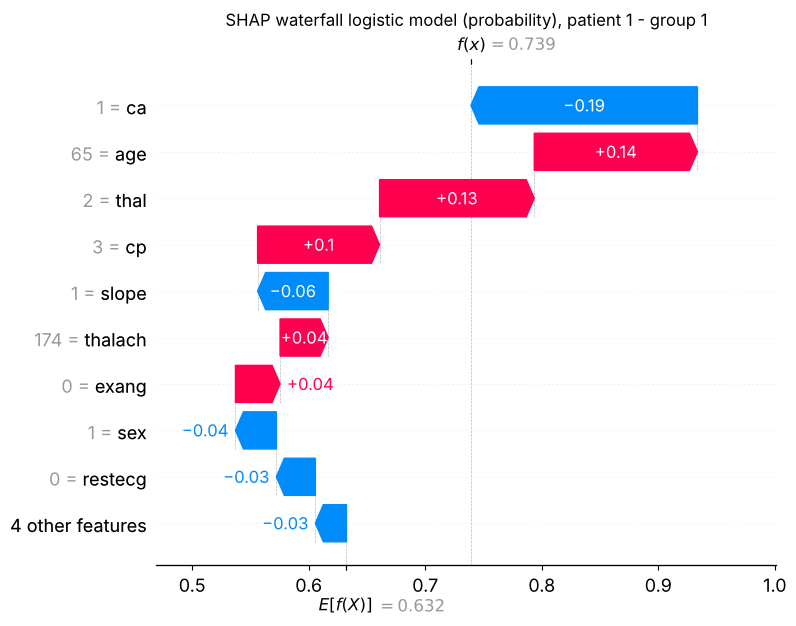

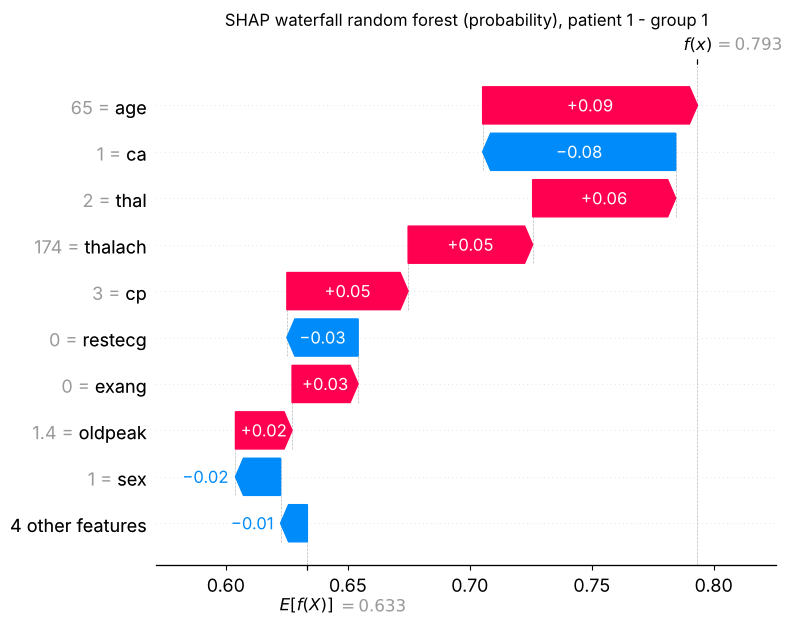

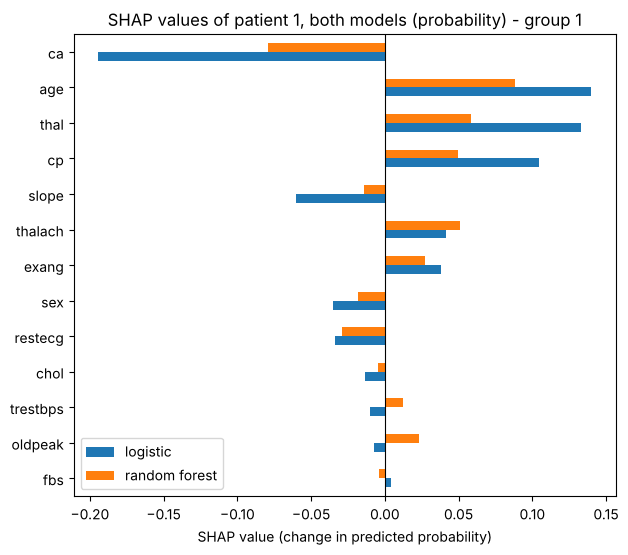

SHAP values of our patient on the probability scale, both models:


,value,logistic,random forest
ca,1.0,-0.194,-0.079
age,65.0,0.140,0.088
thal,2.0,0.133,0.059
cp,3.0,0.105,0.050
slope,1.0,-0.061,-0.014
thalach,174.0,0.041,0.051
exang,0.0,0.038,0.027
sex,1.0,-0.035,-0.018
restecg,0.0,-0.033,-0.029
chol,282.0,-0.014,-0.005


In [21]:
# (b) waterfall of our patient for both models, on the same scale
# The LinearExplainer of Q3 gives log-odds, the TreeExplainer of the random forest gives probabilities.
# To compare the two models on the same scale, we also explain the logistic model on the probability scale,
# with the 13 original attributes (like the random forest). The exact algorithm has no randomness.
f_logreg = lambda data: logreg.predict_proba(pd.DataFrame(data, columns=X.columns))[:, 1]
explainer_lr_prob = shap.Explainer(f_logreg, shap.maskers.Independent(X_train, max_samples=len(X_train)),
                                   algorithm="exact")
sv_lr_prob = explainer_lr_prob(x_p)

print("Predicted probability of heart disease for our patient:")
print("  logistic:", round(logreg.predict_proba(x_p)[0, 1], 3), " random forest:", round(rf.predict_proba(x_p)[0, 1], 3),
      " true label:", y_test.iloc[p])
print("Check on the probability scale, base value + sum of SHAP values:")
print("  logistic:", round(sv_lr_prob.base_values[0], 3), "+", round(sv_lr_prob.values[0].sum(), 3), "=",
      round(sv_lr_prob.base_values[0] + sv_lr_prob.values[0].sum(), 3))
print("  random forest:", round(sv_rf.base_values[p], 3), "+", round(sv_rf.values[p].sum(), 3), "=",
      round(sv_rf.base_values[p] + sv_rf.values[p].sum(), 3))

shap.plots.waterfall(sv_lr_prob[0], max_display=10, show=False)
plt.title(f"SHAP waterfall logistic model (probability), patient {p} - group {GROUP_NUMBER}")
plt.show()
shap.plots.waterfall(sv_rf[p], max_display=10, show=False)
plt.title(f"SHAP waterfall random forest (probability), patient {p} - group {GROUP_NUMBER}")
plt.show()

# both models in one plot with the same axis
shap_both = pd.DataFrame({"value": x_p.iloc[0], "logistic": sv_lr_prob.values[0], "random forest": sv_rf.values[p]})
shap_both = shap_both.sort_values("logistic", key=abs, ascending=False)
shap_both[["logistic", "random forest"]].iloc[::-1].plot.barh(figsize=(7, 6))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("SHAP value (change in predicted probability)")
plt.title(f"SHAP values of patient {p}, both models (probability) - group {GROUP_NUMBER}")
plt.show()

print("SHAP values of our patient on the probability scale, both models:")
shap_both.round(3)

**Your answers:**

a) For both models ca and thal are the most important attributes, and the directions are the same: ca = 0 increases the risk and ca >= 1 lowers it, higher thal lowers the risk and lower thal increases it. For the random forest thal is one column, so in the beeswarm we only see that high values (red, thal = 3) are on the left. Therefore we printed the mean SHAP value per value of thal: thal = 2 gives +0.070 and thal = 3 gives -0.114 (for ca: ca = 0 gives +0.074, ca = 1 gives -0.125). For the logistic model this is the same as the thal_2.0 and thal_3.0 dummies in Q3 a). The random forest is more sensitive to thalach (3rd place, while it is only 12th of the 22 columns in the logistic bar plot of Q3 a) and exang (5th, logistic 7th), and it shows threshold effects, for example the jump of thalach at 140 and oldpeak only having an effect above 1.5 (see Q2). The logistic model gives more weight to age (2nd, random forest 4th) and sex (4th, random forest 8th) and can only model linear effects. From Q1 c) we also know that the random forest overfits on age and ca.


b) Both models predict heart disease for our patient: the predicted probability is 0.739 for the logistic model and 0.793 for the random forest, but the patient is actually healthy, so both models are wrong. The SHAP values of a logistic model are usually given in log-odds (for our patient f(x) = 1.042, which is a probability of 0.739), while the TreeExplainer gives the SHAP values of the random forest in probabilities. To compare the two models on the same scale, we explained the logistic model on the probability scale, with the 13 original attributes like the random forest. Now both waterfalls start at almost the same base value (0.632 and 0.633, the average predicted probability on the training set) and end at the predicted probability (0.632 + 0.107 = 0.739 and 0.633 + 0.16 = 0.793).

The two explanations agree on the direction of the most important attributes: ca = 1 pushes towards no disease (logistic -0.194, random forest -0.079), and age = 65 (+0.140 / +0.088), thal = 2 (+0.133 / +0.059) and cp = 3 (+0.105 / +0.050) push towards disease. The logistic model gives clearly larger values to these four attributes. For the random forest thalach (+0.051) is about as important as cp, and oldpeak has the opposite sign (+0.023, logistic -0.007).

To decide which model and explanation we would show to a doctor, we compare what permutation importance, PDP and SHAP told us about both models:

| | Logistic model | Random forest |
|---|---|---|
| Completeness | The coefficients and SHAP describe the whole model exactly: on the log-odds scale the SHAP value is beta * (x - mean), for example for age 0.7487 * (1.1668 - 0) = 0.8735. The PDPs are straight lines, so one number per attribute is enough. | SHAP explains one patient exactly, but the global behaviour (jumps, interactions) needs many PDP/ICE plots, and the 300 trees themselves cannot be shown. |
| Comprehensibility | Every attribute always works in the same direction for all patients (parallel ICE lines). On the probability scale its waterfall is as easy to read as the one of the random forest. | The waterfall is easy to read, but effects with jumps (thalach at 140, oldpeak only above 1.5) are harder to explain medically. |
| Stability | Train accuracy 0.858 and test accuracy 0.812, so it hardly overfits. SHAP is exact and does not depend on randomness. | Train accuracy 1.0 and test accuracy 0.812, it overfits: ca (0.065) and age (0.057) have the highest permutation importance on the training set but about 0 on the test set (-0.001). |

We would show the logistic model to the doctor, with the waterfall on the probability scale. It has the same test accuracy (0.812) and a higher AUC (0.888 vs 0.845), and its explanation is more complete and more stable. For our patient we would explain it like this: "one coloured vessel (ca = 1) lowers the predicted risk by about 19 percentage points, while the age of 65, thal = 2 and chest pain type 3 each increase it by 10 to 14 percentage points". This also shows the doctor why the model is wrong for this patient: the prediction is mainly driven by age, thal and cp.

## Q5) Find the hidden change

a) **[Advanced]** The data of your group has one hidden change compared to the original data set (`data/heart_original.csv`). For example, the effect of one attribute was made stronger, or one attribute was made to depend on another one. Use the methods of this lab on both data sets to find the change. Which attribute(s) were changed, and what kind of change is it? Show the plots that support your answer. Which method was most useful, and which one did not show the change?

In [22]:
original = pd.read_csv("data/heart_original.csv", sep=",", header=0, decimal=".")
print("Number of rows: original", len(original), ", our file", len(df))
print("Fraction of patients with heart disease: original", original["target"].mean().round(3), ", our file", df["target"].mean().round(3))
print()
print("Correlation of every attribute with the target, original data vs our data:")
print(pd.DataFrame({"original": original.corr()["target"], "group 1": df.corr()["target"]}).round(3))

Number of rows: original 303 , our file 273
Fraction of patients with heart disease: original 0.545 , our file 0.634

Correlation of every attribute with the target, original data vs our data:
          original  group 1
age         -0.225   -0.021
sex         -0.281   -0.291
cp           0.434    0.358
trestbps    -0.145   -0.101
chol        -0.085   -0.045
fbs         -0.028   -0.085
restecg      0.137    0.068
thalach      0.422    0.318
exang       -0.437   -0.385
oldpeak     -0.431   -0.353
slope        0.346    0.305
ca          -0.392   -0.272
thal        -0.344   -0.365
target       1.000    1.000


Random forest: permutation importance on the test set, original data vs our data:
          original  group 1
age         -0.018   -0.001
sex          0.010    0.010
cp           0.014    0.032
trestbps    -0.013    0.008
chol         0.009    0.010
fbs         -0.002    0.003
restecg      0.017    0.011
thalach     -0.008   -0.004
exang        0.032    0.023
oldpeak      0.013    0.021
slope        0.014    0.021
ca           0.075   -0.001
thal         0.047    0.062


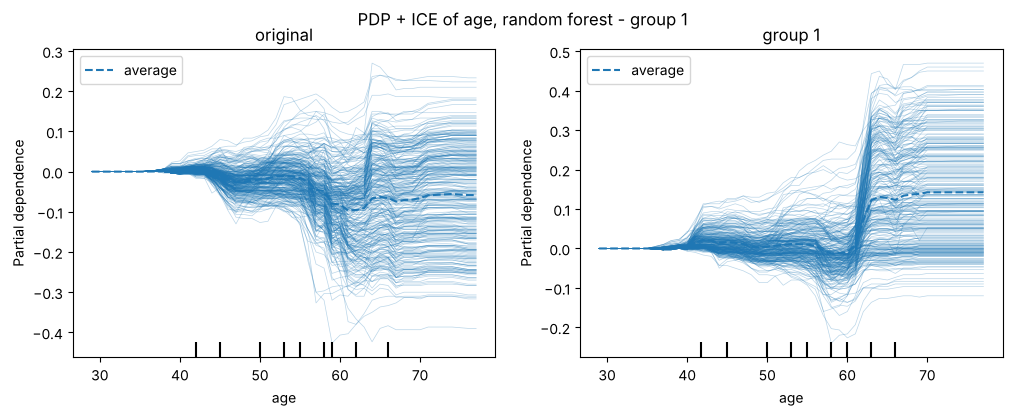

original: mean SHAP value of age for age <= 60: 0.01 , for age > 60: -0.034


group 1: mean SHAP value of age for age <= 60: -0.037 , for age > 60: 0.088


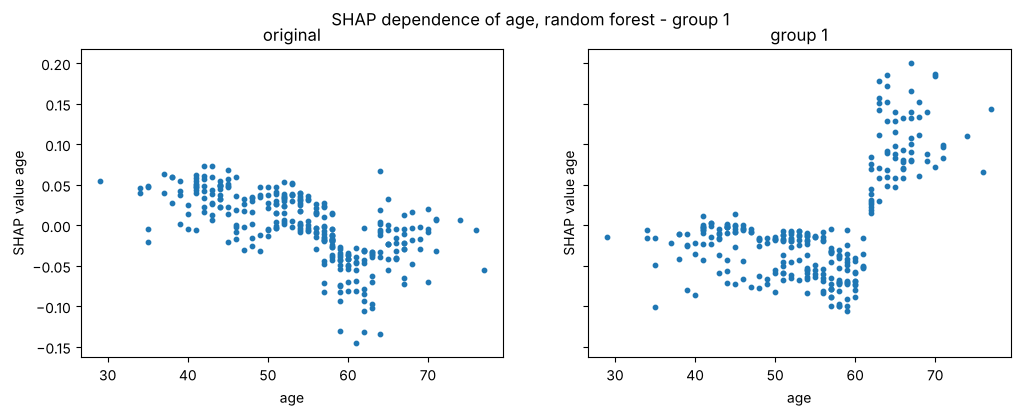

In [23]:
# fit a random forest on the original data in the same way and compare
Xo = original.drop(columns="target").astype(float)
yo = original["target"]
Xo_train, Xo_test, yo_train, yo_test = train_test_split(Xo, yo, test_size=0.25, stratify=yo, random_state=S)
rf_o = RandomForestClassifier(n_estimators=300, random_state=S).fit(Xo_train, yo_train)

ro = permutation_importance(rf_o, Xo_test, yo_test, n_repeats=30, random_state=S)
print("Random forest: permutation importance on the test set, original data vs our data:")
print(pd.DataFrame({"original": ro.importances_mean, "group 1": perm["random forest"]}, index=X.columns).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
PartialDependenceDisplay.from_estimator(rf_o, Xo, ["age"], kind="both", centered=True, random_state=S, ax=axes[0])
PartialDependenceDisplay.from_estimator(rf, X, ["age"], kind="both", centered=True, random_state=S, ax=axes[1])
axes[0].set_title("original"); axes[1].set_title("group 1")
fig.suptitle(f"PDP + ICE of age, random forest - group {GROUP_NUMBER}")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, model, data, title in [(axes[0], rf_o, Xo, "original"), (axes[1], rf, X, "group 1")]:
    s = shap.TreeExplainer(model)(data)[..., 1]
    ax.scatter(data["age"], s[:, "age"].values, s=10)
    ax.set_xlabel("age"); ax.set_ylabel("SHAP value age"); ax.set_title(title)
    print(f"{title}: mean SHAP value of age for age <= 60:", round(s[:, "age"].values[data["age"] <= 60].mean(), 3),
          ", for age > 60:", round(s[:, "age"].values[data["age"] > 60].mean(), 3))
fig.suptitle(f"SHAP dependence of age, random forest - group {GROUP_NUMBER}")
plt.show()

In [24]:
# looks like something happens at age 60: check the target per age group
rate = pd.DataFrame({"original": original.groupby(original["age"] > 60)["target"].mean(),
                     "group 1": df.groupby(df["age"] > 60)["target"].mean()}).round(2)
rate.index = ["age <= 60", "age > 60"]
print("Fraction of patients with heart disease per age group:")
print(rate)
print()

# find the same patients in both files and compare the labels
both = df.merge(original, on=list(X.columns), suffixes=("", "_original"))
changed = both[both["target"] != both["target_original"]]
print(len(changed), "labels changed, all from", changed["target_original"].unique(), "to", changed["target"].unique())
print("age of changed patients:", changed["age"].min(), "-", changed["age"].max())
print("healthy patients > 60 in original:", ((original["age"] > 60) & (original["target"] == 0)).sum())

Fraction of patients with heart disease per age group:
           original  group 1
age <= 60      0.58     0.58
age > 60       0.44     0.78

23 labels changed, all from [0] to [1]
age of changed patients: 61 - 77
healthy patients > 60 in original: 44


**Your answers:**

a) The change is in the target and depends on age. The correlation of age with the target changes from -0.225 to -0.021, and for patients older than 60 the disease rate goes from 0.44 to 0.78, while for the younger patients it stays 0.58. When we compare the same patients in both files, 23 labels were changed from 0 to 1 and all of these patients are 61 or older (out of 44 healthy patients above 60 in the original). So the effect of age was made stronger with a threshold at 60. (Also 30 rows were removed.)
The PDP/ICE of age for the random forest shows this best: on the original data it decreases slightly, but on our data there is a jump of about +0.14 at 60. The SHAP dependence plot shows the same jump: in the original data the mean SHAP value of age is 0.010 for age <= 60 and -0.034 above 60, while in our data it is -0.037 below 60 and +0.088 above 60 (single patients up to +0.2). Permutation importance did not show the change, because age is about 0 in both data sets: only part of the old patients were relabelled, so it acts like noise that does not improve the test accuracy.